In [1]:
!pip list

Package                   Version
------------------------- -----------
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.4.22
cffi                      2.0.0
charset-normalizer        3.4.7
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.63.0
fqdn                      1.5.1
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna                      3.13
ipykernel        

In [2]:
libraries = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'sklearn']

print("=== PROJECT LIBRARY CHECK ===")
for lib in libraries:
    try:
        __import__(lib)
        print(f"🟢 {lib}: Installed")
    except ImportError:
        print(f"🔴 {lib}: NOT Installed")

=== PROJECT LIBRARY CHECK ===
🟢 pandas: Installed
🟢 numpy: Installed
🟢 matplotlib: Installed
🟢 seaborn: Installed
🟢 sklearn: Installed


# 📊 RavenStack SaaS Customer Churn & Retention Analytics
### Phase 1: Environment Initialization & Data Ingestion
*Objective: Load all relational tables to perform an initial data health and shape audit.*

In [3]:
import pandas as pd

# Load all 5 RavenStack CSV files
df_accounts = pd.read_csv('ravenstack_accounts.csv')
df_subs = pd.read_csv('ravenstack_subscriptions.csv')
df_usage = pd.read_csv('ravenstack_feature_usage.csv')
df_tickets = pd.read_csv('ravenstack_support_tickets.csv')
df_churn = pd.read_csv('ravenstack_churn_events.csv')

# Verify dataset dimensions (Rows, Columns)
print("=== RAVENSTACK DATASET SHAPES ===")
print(f"Accounts shape:        {df_accounts.shape}")
print(f"Subscriptions shape:   {df_subs.shape}")
print(f"Feature Usage shape:   {df_usage.shape}")
print(f"Support Tickets shape: {df_tickets.shape}")
print(f"Churn Events shape:    {df_churn.shape}")

=== RAVENSTACK DATASET SHAPES ===
Accounts shape:        (500, 10)
Subscriptions shape:   (5000, 14)
Feature Usage shape:   (25000, 8)
Support Tickets shape: (2000, 9)
Churn Events shape:    (600, 9)


### Phase 2: Data Health, Null Value & Data Type Audit
*Objective: Identify missing values, inconsistent column data types, and potential data quality issues across all 5 tables.*

In [4]:
# Create a dictionary of all loaded DataFrames
dfs = {
    'Accounts': df_accounts,
    'Subscriptions': df_subs,
    'Feature Usage': df_usage,
    'Support Tickets': df_tickets,
    'Churn Events': df_churn
}

print("=== MISSING VALUE & DATA HEALTH AUDIT ===")
for name, df in dfs.items():
    null_counts = df.isnull().sum()
    total_nulls = null_counts.sum()
    print(f"\n📌 {name} Table (Total Rows: {len(df)})")
    if total_nulls == 0:
        print("   🟢 No missing values!")
    else:
        print(f"   🔴 Found missing values:")
        for col, count in null_counts[null_counts > 0].items():
            pct = (count / len(df)) * 100
            print(f"      - {col}: {count} missing ({pct:.1f}%)")

=== MISSING VALUE & DATA HEALTH AUDIT ===

📌 Accounts Table (Total Rows: 500)
   🟢 No missing values!

📌 Subscriptions Table (Total Rows: 5000)
   🔴 Found missing values:
      - end_date: 4514 missing (90.3%)

📌 Feature Usage Table (Total Rows: 25000)
   🟢 No missing values!

📌 Support Tickets Table (Total Rows: 2000)
   🔴 Found missing values:
      - satisfaction_score: 825 missing (41.2%)

📌 Churn Events Table (Total Rows: 600)
   🔴 Found missing values:
      - feedback_text: 148 missing (24.7%)


In [5]:
# 1. Fill text missing values logically
df_churn['feedback_text'] = df_churn['feedback_text'].fillna('No Feedback Provided')

# 2. Convert all Date columns to proper Pandas Datetime format across tables
date_cols = {
    'Accounts': (df_accounts, ['signup_date']),
    'Subscriptions': (df_subs, ['start_date', 'end_date']),
    'Feature Usage': (df_usage, ['usage_date']),
    'Support Tickets': (df_tickets, ['created_at', 'resolved_at']),
    'Churn Events': (df_churn, ['churn_date'])
}

for name, (df, cols) in date_cols.items():
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

# 3. Create an explicit 'is_churned' boolean flag on subscriptions
df_subs['is_churned'] = df_subs['end_date'].notnull().astype(int)

print("✅ Data cleaning complete!")
print(f"Total Subscriptions: {len(df_subs)}")
print(f"Active Subscriptions: {(df_subs['is_churned'] == 0).sum()}")
print(f"Churned Subscriptions: {(df_subs['is_churned'] == 1).sum()}")

✅ Data cleaning complete!
Total Subscriptions: 5000
Active Subscriptions: 4514
Churned Subscriptions: 486


### Phase 3: Relational Feature Aggregation & Master Dataset Creation
*Objective: Roll up high-frequency event logs (Feature Usage & Support Tickets) to the account level, then perform SQL-style joins to build a unified analytics dataset.*

In [6]:
# 1. Aggregate Feature Usage logs to Account level
usage_agg = df_usage.groupby('subscription_id').agg(
    total_usage_events=('feature_name', 'count'),
    total_usage_mins=('usage_duration_secs', lambda x: x.sum() / 60),
    total_errors=('error_count', 'sum'),
    distinct_active_days=('usage_date', lambda x: x.dt.date.nunique())
).reset_index()

# 2. Aggregate Support Tickets to Account level
tickets_agg = df_tickets.groupby('account_id').agg(
    total_support_tickets=('ticket_id', 'count'),
    avg_satisfaction_score=('satisfaction_score', 'mean'),
    avg_resolution_time_hrs=('resolution_time_hours', 'mean'),
).reset_index()

# 3. Build Master DataFrame starting with Subscriptions
df_master = df_subs.copy()

# Select unique profile columns from df_accounts to avoid duplicate columns
account_profile_cols = ['account_id','account_name','industry','country','signup_date','referral_source']
df_master = df_master.merge(df_accounts[account_profile_cols], on='account_id', how='left')

# Merge Usage stats (on subscription_id) and Support stats (on account_id)
df_master=df_master.merge(usage_agg,on='subscription_id',how='left')
df_master=df_master.merge(tickets_agg,on='account_id',how='left')

# 4. Fill missing values for accounts with 0 usage or 0 support tickets
df_master['total_usage_events']= df_master['total_usage_events'].fillna(0)
df_master['total_usage_mins']= df_master['total_usage_mins'].fillna(0)
df_master['total_errors']= df_master['total_errors'].fillna(0)
df_master['distinct_active_days']= df_master['distinct_active_days'].fillna(0)
df_master['total_support_tickets']= df_master['total_support_tickets'].fillna(0)

print("=== MASTER DATASET CREATION COMPLETE ===")
print(F"MASTER TABLE SHAPE: {df_master.shape}")
df_master.head(10)









=== MASTER DATASET CREATION COMPLETE ===
MASTER TABLE SHAPE: (5000, 27)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,...,country,signup_date,referral_source,total_usage_events,total_usage_mins,total_errors,distinct_active_days,total_support_tickets,avg_satisfaction_score,avg_resolution_time_hrs
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,...,UK,2023-08-26,event,6.0,440.300000,2.0,6.0,4.0,3.500000,33.25
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,...,AU,2023-09-28,other,4.0,113.650000,6.0,4.0,4.0,4.000000,33.50
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,...,IN,2023-11-17,event,3.0,231.283333,2.0,3.0,4.0,4.333333,8.00
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,...,US,2024-06-23,event,7.0,382.383333,5.0,7.0,1.0,4.000000,45.00
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,...,US,2023-10-29,ads,0.0,0.000000,0.0,0.0,6.0,4.000000,31.50
5,S-4b9b13,A-fa2041,2024-08-13,NaT,Pro,15,735,8820,False,False,...,US,2024-05-29,organic,5.0,209.683333,2.0,5.0,1.0,3.000000,16.00
6,S-dceac6,A-417d2f,2023-12-30,NaT,Enterprise,4,796,9552,False,False,...,IN,2023-07-04,partner,3.0,232.150000,2.0,3.0,6.0,4.333333,43.50
7,S-8cad7b,A-5f2961,2024-12-23,NaT,Basic,16,304,3648,False,False,...,US,2024-11-22,partner,3.0,237.416667,2.0,3.0,1.0,NaN,53.00
8,S-24796e,A-cc8c8f,2024-11-27,NaT,Enterprise,23,4577,54924,False,False,...,US,2024-06-16,ads,6.0,212.883333,3.0,6.0,2.0,3.500000,14.50
9,S-d0c344,A-80eeb6,2024-10-27,NaT,Pro,22,1078,12936,False,False,...,UK,2023-05-09,organic,8.0,404.483333,8.0,8.0,4.0,3.666667,40.25


In [7]:
# Check column names across all DataFrames
print("=== COLUMN NAMES CHECK ===")
print(f"df_accounts:  {list(df_accounts.columns)}")
print(f"df_subs:      {list(df_subs.columns)}")
print(f"df_usage:     {list(df_usage.columns)}")
print(f"df_tickets:   {list(df_tickets.columns)}")
print(f"df_churn:     {list(df_churn.columns)}")

=== COLUMN NAMES CHECK ===
df_accounts:  ['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']
df_subs:      ['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag', 'is_churned']
df_usage:     ['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']
df_tickets:   ['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']
df_churn:     ['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']


### Phase 4: Exploratory Data Analysis (EDA) & Churn Metrics Breakdown
*Objective: Calculate overall customer/revenue churn rates and slice churn risk across plan tiers and subscription attributes.*

In [8]:
total_subs = len(df_master)
churned_subs = df_master['is_churned'].sum()
churn_rate = (churned_subs / total_subs) * 100

print(f"Logo Churn Rate: {churn_rate:.2f}%")

Logo Churn Rate: 9.72%


In [9]:
total_mrr = df_master['mrr_amount'].sum()
churned_mrr = df_master[df_master['is_churned'] == 1]['mrr_amount'].sum()
mrr_churn_rate = (churned_mrr / total_mrr) *100

print(f"MRR Churn Rate: {mrr_churn_rate:.2f}%")

MRR Churn Rate: 10.40%


In [10]:
# Group by plan_tier and calculate the average churn rate
plan_churn = df_master.groupby('plan_tier')['is_churned'].mean() *100
print(plan_churn)

plan_tier
Basic         9.488140
Enterprise    9.982589
Pro           9.671642
Name: is_churned, dtype: float64


In [11]:
# if churned users have less activity than active users:
usage_comparison = df_master.groupby('is_churned')['total_usage_events'].mean()
print(usage_comparison)

is_churned
0    5.012627
1    4.882716
Name: total_usage_events, dtype: float64


In [12]:
#Let's compare the average total errors (total_errors) between active (0) and churned (1) users.
error_comparison = df_master.groupby('is_churned')['total_errors'].mean()
print(error_comparison)

is_churned
0    2.827647
1    2.763374
Name: total_errors, dtype: float64


In [13]:
sat_comparison = df_master.groupby('is_churned')['avg_satisfaction_score'].mean()
print(sat_comparison)

is_churned
0    3.973535
1    3.957908
Name: avg_satisfaction_score, dtype: float64


#We just systematically ruled out three major hypotheses:

❌ Low product engagement / ghosting

❌ High technical errors / bugs

❌ Poor customer support experience

In [14]:
reason_counts = df_churn['reason_code'].value_counts()
print(reason_counts)

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: count, dtype: int64


In [15]:
#🔍 Key Key Business Insights from the Reasons:
#features (114) is the single largest individual driver of churn. Customers feel the product is missing capabilities they need.

#Cost/Price sensitivity: If you combine budget (104) and pricing (91), financial/pricing concerns account for 195 total churn events
#(nearly 32% of all churn)!

In [16]:
reason_pcts = df_churn['reason_code'].value_counts(normalize=True) *100
print(reason_pcts)

reason_code
features      19.000000
support       17.333333
budget        17.333333
unknown       15.833333
competitor    15.333333
pricing       15.166667
Name: proportion, dtype: float64


In [17]:
#🛠️ Missing Features: 19.00% (Top single reason)

#💰 Financial Impact (budget + pricing): 32.50% (Combined total!)

#🎧 Support Issues: 17.33%

#⚔️ Competitor Switch: 15.33%

#Combining budget (17.33%) and pricing (15.17%) shows that nearly 1 in every 3 churned customers left due to cost concerns.
#That is a huge insight for executive strategy.

In [18]:
import matplotlib.pyplot as plt

<Axes: ylabel='reason_code'>

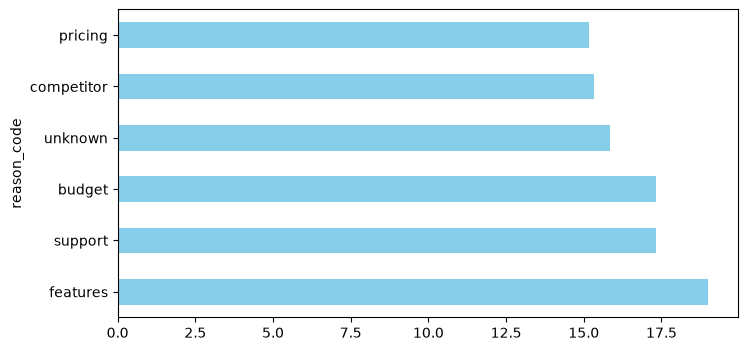

In [19]:
# 1.horizontal bar plot ('barh')
reason_pcts.plot(kind='barh', color='skyblue', figsize=(8, 4))

### Logo Churn: 9.72%#

#### MRR Churn: 10.40% (Revenue leak is slightly worse than raw account loss)

#### Highest Risk Tier: Enterprise (9.98% churn)

#### Root Causes: Features (19%), Budget + Pricing (32.5%), Support (17.3%)

In [20]:
source_churn = df_master.groupby('referral_source')['is_churned'].mean() * 100
print(source_churn)

referral_source
ads         9.900000
event      10.032715
organic    10.854701
other       8.860759
partner     8.690745
Name: is_churned, dtype: float64


In [21]:
# 📈 Highest Churn: organic (10.85%) — Users coming from search engines or direct traffic leave at a higher rate.

# 📉 Lowest Churn: partner (8.69%) — Customers referred through strategic partners stay around the longest!

#🎟️ Events & Ads: Hovering right around the average at 10.03% and 9.90%.

In [22]:
high_risk_condition = (df_master['total_usage_events'] <= 3) & (df_master['total_support_tickets'] >0)
df_master['is_high_risk'] = high_risk_condition.astype(int)
print(df_master['is_high_risk'].value_counts())

is_high_risk
0    3670
1    1330
Name: count, dtype: int64


In [23]:
# That means 26.6% of total account base is showing early warning signs (low usage combined with open/logged support tickets).

In [24]:
active_high_risk_mrr = df_master[(df_master['is_high_risk'] == 1) & (df_master['is_churned'] ==0)]['mrr_amount'].sum()
print(f"Total MRR At High Risk: ${active_high_risk_mrr:,.2f}")

Total MRR At High Risk: $2,652,282.00


In [25]:
# Filter active, high-risk accounts and select key columns for CS
high_risk_export = df_master[(df_master['is_high_risk'] == 1) & (df_master['is_churned'] == 0)][
    ['account_id', 'plan_tier', 'mrr_amount', 'total_usage_events', 'total_support_tickets', 'referral_source']
]

# Sort by highest MRR to prioritize high-value clients
high_risk_export = high_risk_export.sort_values(by='mrr_amount', ascending=False)

# Export to CSV
high_risk_export.to_csv('high_risk_accounts_action_list.csv', index=False)
print(f"Successfully exported {len(high_risk_export)} accounts to high_risk_accounts_action_list.csv!")

Successfully exported 1205 accounts to high_risk_accounts_action_list.csv!


In [26]:
# Export master dataframe for Power BI dashboarding
df_master.to_csv('df_master_powerbi.csv', index=False)
print(f"Master dataset successfully exported ({len(df_master)} total rows)!")

Master dataset successfully exported (5000 total rows)!


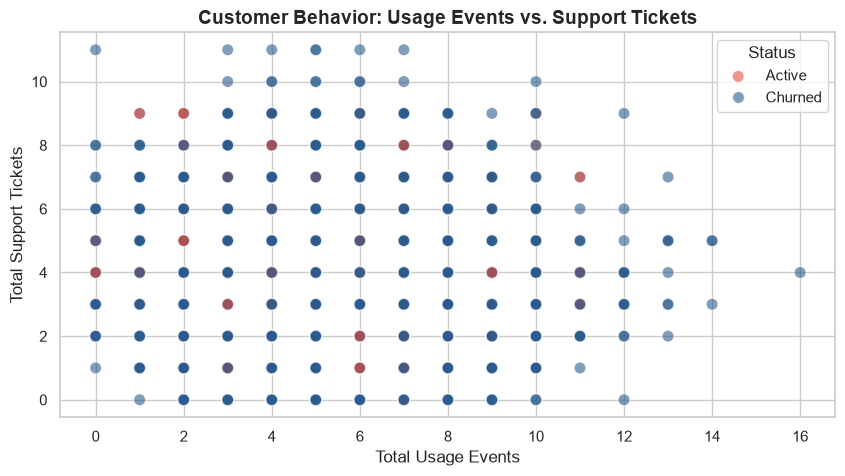

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Initialize figure
plt.figure(figsize=(10, 5))

# Build Scatter Plot
sns.scatterplot(
    data=df_master,
    x='total_usage_events',
    y='total_support_tickets',
    hue='is_churned',
    palette={0: '#2b5c8f', 1: '#e74c3c'}, # Cool blue for active, crimson red for churned
    alpha=0.6,
    s=70
)

plt.title('Customer Behavior: Usage Events vs. Support Tickets', fontsize=14, fontweight='bold')
plt.xlabel('Total Usage Events', fontsize=12)
plt.ylabel('Total Support Tickets', fontsize=12)
plt.legend(title='Status', labels=['Active', 'Churned'])

plt.show()

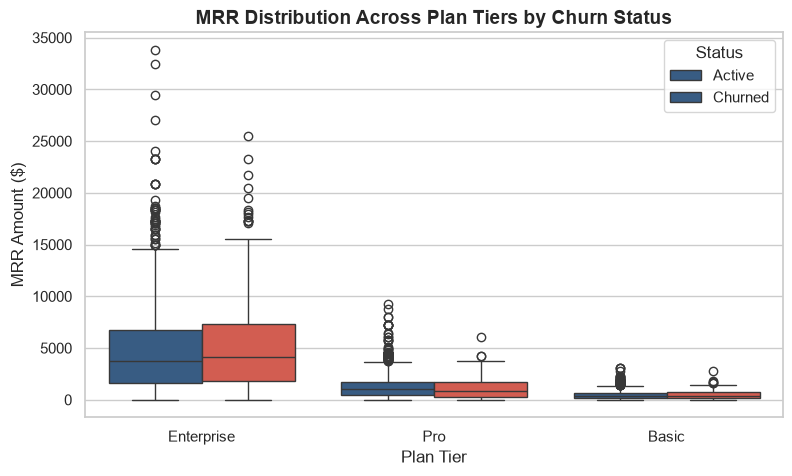

In [28]:
# Initialize figure
plt.figure(figsize=(9, 5))

# Build Box Plot
sns.boxplot(
    data=df_master,
    x='plan_tier',
    y='mrr_amount',
    hue='is_churned',
    palette={0: '#2b5c8f', 1: '#e74c3c'}
)

plt.title('MRR Distribution Across Plan Tiers by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Plan Tier', fontsize=12)
plt.ylabel('MRR Amount ($)', fontsize=12)
plt.legend(title='Status', labels=['Active', 'Churned'])

plt.show()